# Statistical Customer Segmentation System

## Notebook 04: Dimensionality Reduction (PCA)

### Purpose

This notebook applies Principal Component Analysis (PCA) to reduce dimensional complexity while preserving the dominant patterns of customer behavior.

### Objectives

- Standardize RFM variables
- Apply Principal Component Analysis
- Examine explained variance
- Visualize customer behavior in reduced dimensions
- Prepare data for clustering

### Expected Outcome

A lower-dimensional representation of customer behavior suitable for clustering and segmentation.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import os

os.makedirs("images", exist_ok=True)

In [2]:
rfm = pd.read_csv(
    "rfm_dataset.csv",
    index_col=0
)

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12347.0,37,1,711.79
12348.0,27,1,892.80
12359.0,1,1,547.50
12370.0,27,2,1864.27
12377.0,24,1,1001.52


## RFM Dataset Overview

In [3]:
print("Shape:", rfm.shape)

rfm.describe()

Shape: (1104, 3)


,Recency,Frequency,Monetary
count,1104.000000,1104.000000,1104.000000
mean,24.298007,2.307971,865.032228
std,14.082742,12.161399,6361.916853
min,1.000000,1.000000,-1192.200000
25%,8.000000,1.000000,173.297500
50%,28.500000,1.000000,318.620000
75%,36.000000,2.000000,606.340000
max,43.000000,399.000000,204223.960000


## Feature Standardization

PCA is sensitive to scale. Therefore, all RFM variables are standardized prior to dimensionality reduction.

In [4]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm
)

rfm_scaled[:5]

array([[ 0.90236329, -0.10759977, -0.02409835],
       [ 0.19195248, -0.10759977,  0.00436666],
       [-1.6551156 , -0.10759977, -0.04993403],
       [ 0.19195248, -0.02533513,  0.1571367 ],
       [-0.02117076, -0.10759977,  0.0214636 ]])

In [5]:
pd.DataFrame(
    rfm_scaled,
    columns=rfm.columns
).describe()

,Recency,Frequency,Monetary
count,1.104000e+03,1.104000e+03,1.104000e+03
mean,-5.148860e-17,1.609019e-17,6.436076e-18
std,1.000453e+00,1.000453e+00,1.000453e+00
min,-1.655116e+00,-1.075998e-01,-3.235133e-01
25%,-1.157828e+00,-1.075998e-01,-1.087798e-01
50%,2.985141e-01,-1.075998e-01,-8.592691e-02
75%,8.313222e-01,-2.533513e-02,-4.068105e-02
max,1.328610e+00,3.263373e+01,3.197953e+01


## Principal Component Analysis

In [6]:
pca = PCA()

pca.fit(
    rfm_scaled
)

PCA()

In [7]:
explained_variance = (
    pca.explained_variance_ratio_
)

explained_variance

array([0.66248843, 0.32644889, 0.01106268])

In [8]:
variance_df = pd.DataFrame(
    {
        "Principal Component":
        ["PC1","PC2","PC3"],

        "Explained Variance":
        explained_variance
    }
)

variance_df

,Principal Component,Explained Variance
0,PC1,0.662488
1,PC2,0.326449
2,PC3,0.011063


## Explained Variance Analysis

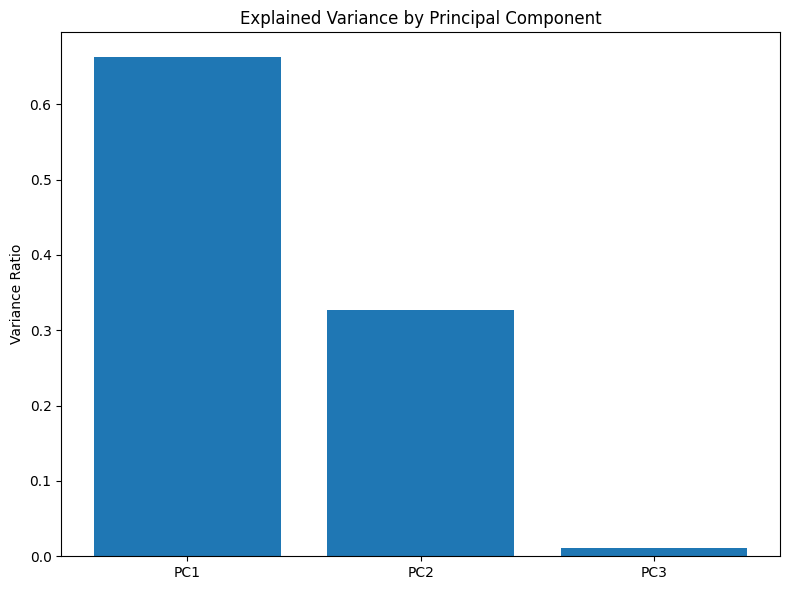

In [9]:
plt.figure(figsize=(8,6))

plt.bar(
    ["PC1","PC2","PC3"],
    explained_variance
)

plt.title(
    "Explained Variance by Principal Component"
)

plt.ylabel(
    "Variance Ratio"
)

plt.tight_layout()

plt.savefig(
    "images/pca_explained_variance.png",
    dpi=300
)

plt.show()

In [10]:
cumulative_variance = (
    np.cumsum(
        explained_variance
    )
)

cumulative_variance

array([0.66248843, 0.98893732, 1.        ])

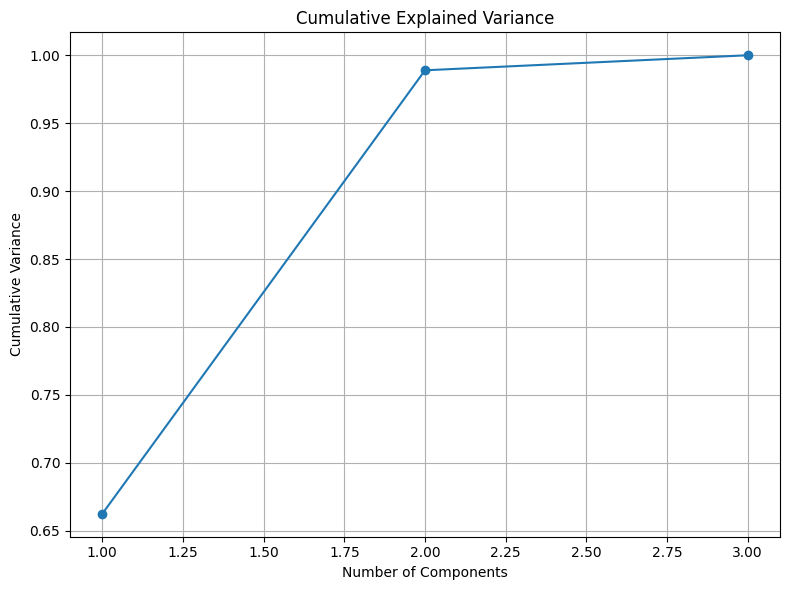

In [11]:
plt.figure(figsize=(8,6))

plt.plot(
    [1,2,3],
    cumulative_variance,
    marker="o"
)

plt.title(
    "Cumulative Explained Variance"
)

plt.xlabel(
    "Number of Components"
)

plt.ylabel(
    "Cumulative Variance"
)

plt.grid()

plt.tight_layout()

plt.savefig(
    "images/cumulative_variance.png",
    dpi=300
)

plt.show()

## Principal Component Loadings

Loadings indicate how strongly each RFM variable contributes to the principal components.

In [12]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1","PC2","PC3"],
    index=rfm.columns
)

loadings

,PC1,PC2,PC3
Recency,-0.143177,0.989690,0.003668
Frequency,0.699640,0.103836,-0.706910
Monetary,0.700003,0.098647,0.707294


## Two-Dimensional Customer Projection

In [14]:
pca_2 = PCA(
    n_components=2
)

rfm_pca = pca_2.fit_transform(
    rfm_scaled
)

rfm_pca.shape

(1104, 2)

In [15]:
pca_df = pd.DataFrame(
    rfm_pca,
    columns=["PC1","PC2"]
)

pca_df.head()

,PC1,PC2
0,-0.221348,0.879510
1,-0.099708,0.179232
2,0.126739,-1.654150
3,0.064788,0.202844
4,-0.057225,-0.030008


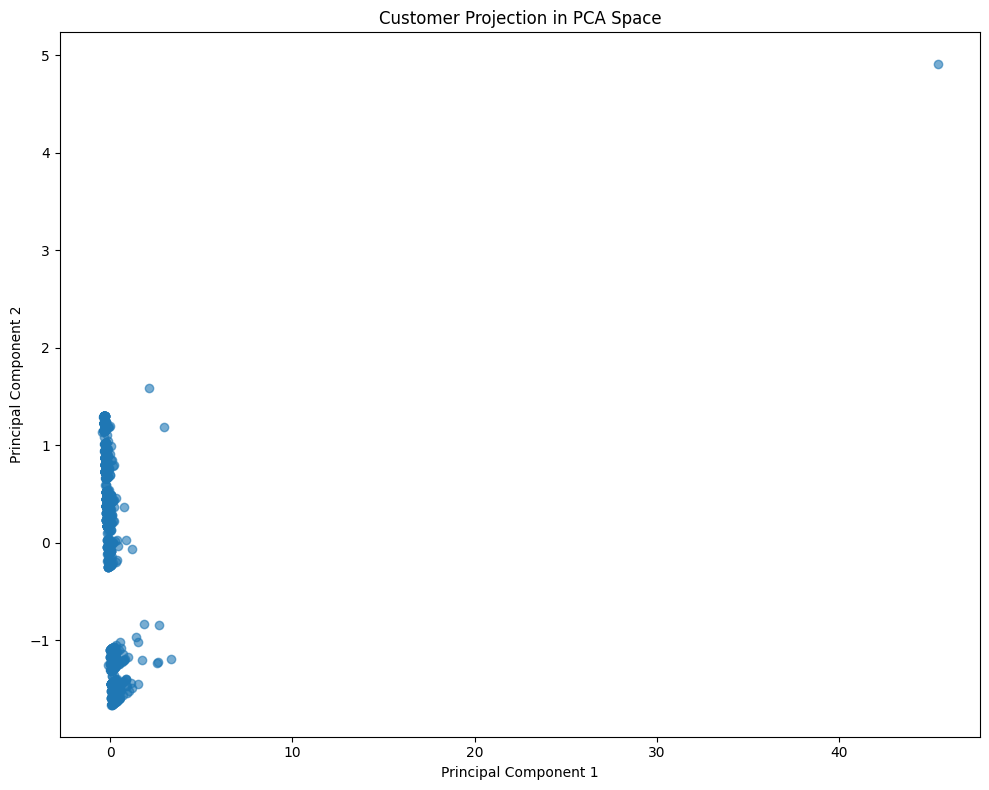

In [16]:
plt.figure(figsize=(10,8))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    alpha=0.6
)

plt.title(
    "Customer Projection in PCA Space"
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.tight_layout()

plt.savefig(
    "images/pca_customer_projection.png",
    dpi=300
)

plt.show()

## PCA Dataset Export

The transformed dataset will be used as input for clustering algorithms.

In [17]:
pca_df.to_csv(
    "pca_dataset.csv",
    index=False
)

print(
    "PCA dataset saved successfully."
)

PCA dataset saved successfully.


## Findings

Principal Component Analysis successfully reduced the dimensional complexity of the RFM dataset while preserving the dominant patterns of customer behavior.

The first principal components captured the majority of variation across customers, indicating that customer purchasing behavior can be represented in a lower-dimensional space without substantial information loss.

These findings support the use of PCA as a preprocessing step for clustering and customer segmentation.